# 🔬 Electron Density Prediction — v3 Improved GAT

**Improvements over v2:**

| # | Change | Motivation |
|---|--------|-----------|
| 1 | **Continuous std-weighted loss** | All nodes contribute; weight = (std+ε)^α so static nodes get tiny (not zero) weight |
| 2 | **Feature-similarity edges** | Replace arbitrary index-sequential edges with top-k cosine-similar density-profile edges |
| 3 | **Spatial coordinate features** | Append normalized (x,y,z) to each node's input so model knows *where* each point is |
| 4 | **Edge-type encoding** | Learnable embedding distinguishes spatial-kNN vs feature-similarity edge types |
| 5 | **Spatial smoothness regularization** | Neighbors in 3D should have similar deltas; penalize sharp spatial discontinuities |

**Task**: Use 5 past timesteps → predict electron density change at next timestep (Ammonia NH₃)

---

In [55]:
# ═══════════════════════════════════════════════════════════════
# 1. IMPORTS & DEVICE SETUP
# ═══════════════════════════════════════════════════════════════
import os, glob, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams.update({'figure.figsize': (12, 6), 'font.size': 12,
                     'axes.titlesize': 13, 'axes.labelsize': 11})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"📦 PyTorch: {torch.__version__}")

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

🖥️  Device: cuda
   GPU: NVIDIA RTX A6000
   VRAM: 50.9 GB
📦 PyTorch: 2.2.1+cu121


## 2. Configuration

In [56]:
# ═══════════════════════════════════════════════════════════════
# 2. CONFIGURATION
# ═══════════════════════════════════════════════════════════════
DATASET_NAME  = "ammonia_x"
DATA_DIR      = Path("../data/raw") / DATASET_NAME
LOOKBACK      = 5
LOOKAHEAD     = 1

# --- Graph construction ---
K_SPATIAL     = 10    # kNN spatial edges (3D physical neighbors)
K_FEATURE     = 8     # feature-similarity edges (top-k cosine-similar density profiles)

# --- Model ---
HIDDEN_DIM    = 128
NUM_LAYERS    = 4
NUM_HEADS     = 4
DROPOUT       = 0.10
# Input dim = LOOKBACK + 3 (x,y,z coordinates)
INPUT_DIM     = LOOKBACK + 3

# --- Loss weights ---
LAMBDA_SMOOTH   = 0.001  # spatial smoothness regularization weight
WARMUP_EPOCHS   = 15     # disable smoothness loss for this many epochs
WEIGHT_ALPHA    = 0.5    # exponent for continuous node weighting: w = (std+eps)^alpha
WEIGHT_EPS      = 1e-12  # prevents zero weight for perfectly static nodes
ACTIVE_THRESHOLD = 1e-6  # for reporting & reference (v2 compatibility)

# --- Training ---
EPOCHS        = 120
LR            = 5e-4
WEIGHT_DECAY  = 1e-4
BATCH_SIZE    = 2
PATIENCE      = 25
GRAD_CLIP     = 1.0

# --- Data ---
TRAIN_RATIO   = 0.80
VAL_RATIO     = 0.10
TEST_RATIO    = 0.10

MODEL_DIR   = Path("../models");  MODEL_DIR.mkdir(exist_ok=True)
REPORTS_DIR = Path("../reports"); REPORTS_DIR.mkdir(exist_ok=True)

print("⚙️  v3 Configuration:")
print(f"   Dataset: {DATASET_NAME}  |  Lookback: {LOOKBACK}  |  Input dim: {INPUT_DIM} (density + xyz)")
print(f"   Graph:   K_spatial={K_SPATIAL}, K_feature={K_FEATURE}  (NO sequential edges)")
print(f"   Loss:    λ_smooth={LAMBDA_SMOOTH}, warmup={WARMUP_EPOCHS} eps")
print(f"   Weights: alpha={WEIGHT_ALPHA} → w=(std+ε)^α, normalized over active nodes")
print(f"   Model:   hidden={HIDDEN_DIM}, layers={NUM_LAYERS}, heads={NUM_HEADS}")
print(f"   Train:   epochs={EPOCHS}, LR={LR}, batch={BATCH_SIZE}, patience={PATIENCE}")

⚙️  v3 Configuration:
   Dataset: ammonia_x  |  Lookback: 5  |  Input dim: 8 (density + xyz)
   Graph:   K_spatial=10, K_feature=8  (NO sequential edges)
   Loss:    λ_smooth=0.001, warmup=15 eps
   Weights: alpha=0.5 → w=(std+ε)^α, normalized over active nodes
   Model:   hidden=128, layers=4, heads=4
   Train:   epochs=120, LR=0.0005, batch=2, patience=25


## 3. Data Loading

Each `rvlab.tdscf.rho.XXXXX` file: 10,540 rows × 2 columns (index | density).
We load all 401 timesteps at once into a **float64** matrix for numerical precision.
The spatial grid coordinates come from `rvlab.tdscf.xyz`.

In [57]:
# ═══════════════════════════════════════════════════════════════
# 3. LOAD ALL DATA (float64 for precision)
# ═══════════════════════════════════════════════════════════════
def load_density_file(fp):
    return np.loadtxt(fp)[:, 1]   # column 1 = density

def load_grid_coords(data_dir):
    coords = []
    reading = False
    with open(data_dir / "rvlab.tdscf.xyz") as f:
        for line in f:
            if '[Grid]' in line:
                reading = True; continue
            if reading:
                p = line.strip().split()
                if len(p) == 4:
                    try: coords.append([float(p[1]), float(p[2]), float(p[3])])
                    except ValueError: pass
    return np.array(coords)

density_files = sorted(
    [f for f in glob.glob(str(DATA_DIR / "rvlab.tdscf.rho.*"))
     if not f.endswith('.xyz') and not f.endswith('.out')],
    key=lambda x: int(x.split('.')[-1])
)
timestep_ids = [int(f.split('.')[-1]) for f in density_files]

print(f"📂 {DATASET_NAME}: {len(density_files)} files, t={timestep_ids[0]}→{timestep_ids[-1]}")
print("⏳ Loading all timesteps into float64 matrix...")

all_raw = np.stack([load_density_file(f) for f in density_files], axis=0).astype(np.float64)
grid_coords = load_grid_coords(DATA_DIR)   # (N, 3) in atomic units (AU)

NUM_NODES = all_raw.shape[1]
NUM_TS    = all_raw.shape[0]

print(f"   Shape: {all_raw.shape}  ({NUM_TS} timesteps × {NUM_NODES} nodes)")
print(f"   Raw density range: [{all_raw.min():.4e}, {all_raw.max():.4f}]")
print(f"   Grid coords shape: {grid_coords.shape}")

# ── LOG1P TRANSFORM (float64) ──────────────────────────────────
all_tf = np.log1p(np.clip(all_raw, 0, None))   # (401, 10540) float64
print(f"   log1p range: [{all_tf.min():.4f}, {all_tf.max():.4f}]  ✅")

📂 ammonia_x: 401 files, t=0→2000
⏳ Loading all timesteps into float64 matrix...
   Shape: (401, 10540)  (401 timesteps × 10540 nodes)
   Raw density range: [7.4166e-17, 196.6391]
   Grid coords shape: (10540, 3)
   log1p range: [0.0000, 5.2864]  ✅


## 4. Dataset Insights

In [58]:
# ═══════════════════════════════════════════════════════════════
# 4. STATS
# ═══════════════════════════════════════════════════════════════

# ── Delta statistics (training only — no leakage) ──────────────
n_samples_total = NUM_TS - LOOKBACK - LOOKAHEAD + 1
n_train_samples = int(TRAIN_RATIO * n_samples_total)
train_ts_end    = n_train_samples + LOOKBACK

all_deltas       = np.diff(all_tf, axis=0)            # (400, 10540) float64
train_deltas     = all_deltas[:train_ts_end - 1]

DELTA_MEAN = train_deltas.mean()
DELTA_STD  = train_deltas.std()
SCALE      = 1.0 / DELTA_STD

per_node_std  = train_deltas.std(axis=0)    # (10540,)
per_node_mean = train_deltas.mean(axis=0)

print(f"📊 Delta statistics (training portion):")
print(f"   Range: [{train_deltas.min():.4e}, {train_deltas.max():.4e}]")
print(f"   Mean (μ): {DELTA_MEAN:.4e}")
print(f"   Std (σ):  {DELTA_STD:.4e}  →  scale = {SCALE:.0f}×")

scaled_demo = (train_deltas - DELTA_MEAN) / DELTA_STD
print(f"   After standardization range: [{scaled_demo.min():.2f}, {scaled_demo.max():.2f}]  ✅")

📊 Delta statistics (training portion):
   Range: [-4.7382e-04, 4.7450e-04]
   Mean (μ): -5.6923e-11
   Std (σ):  6.3393e-05  →  scale = 15774×
   After standardization range: [-7.47, 7.49]  ✅


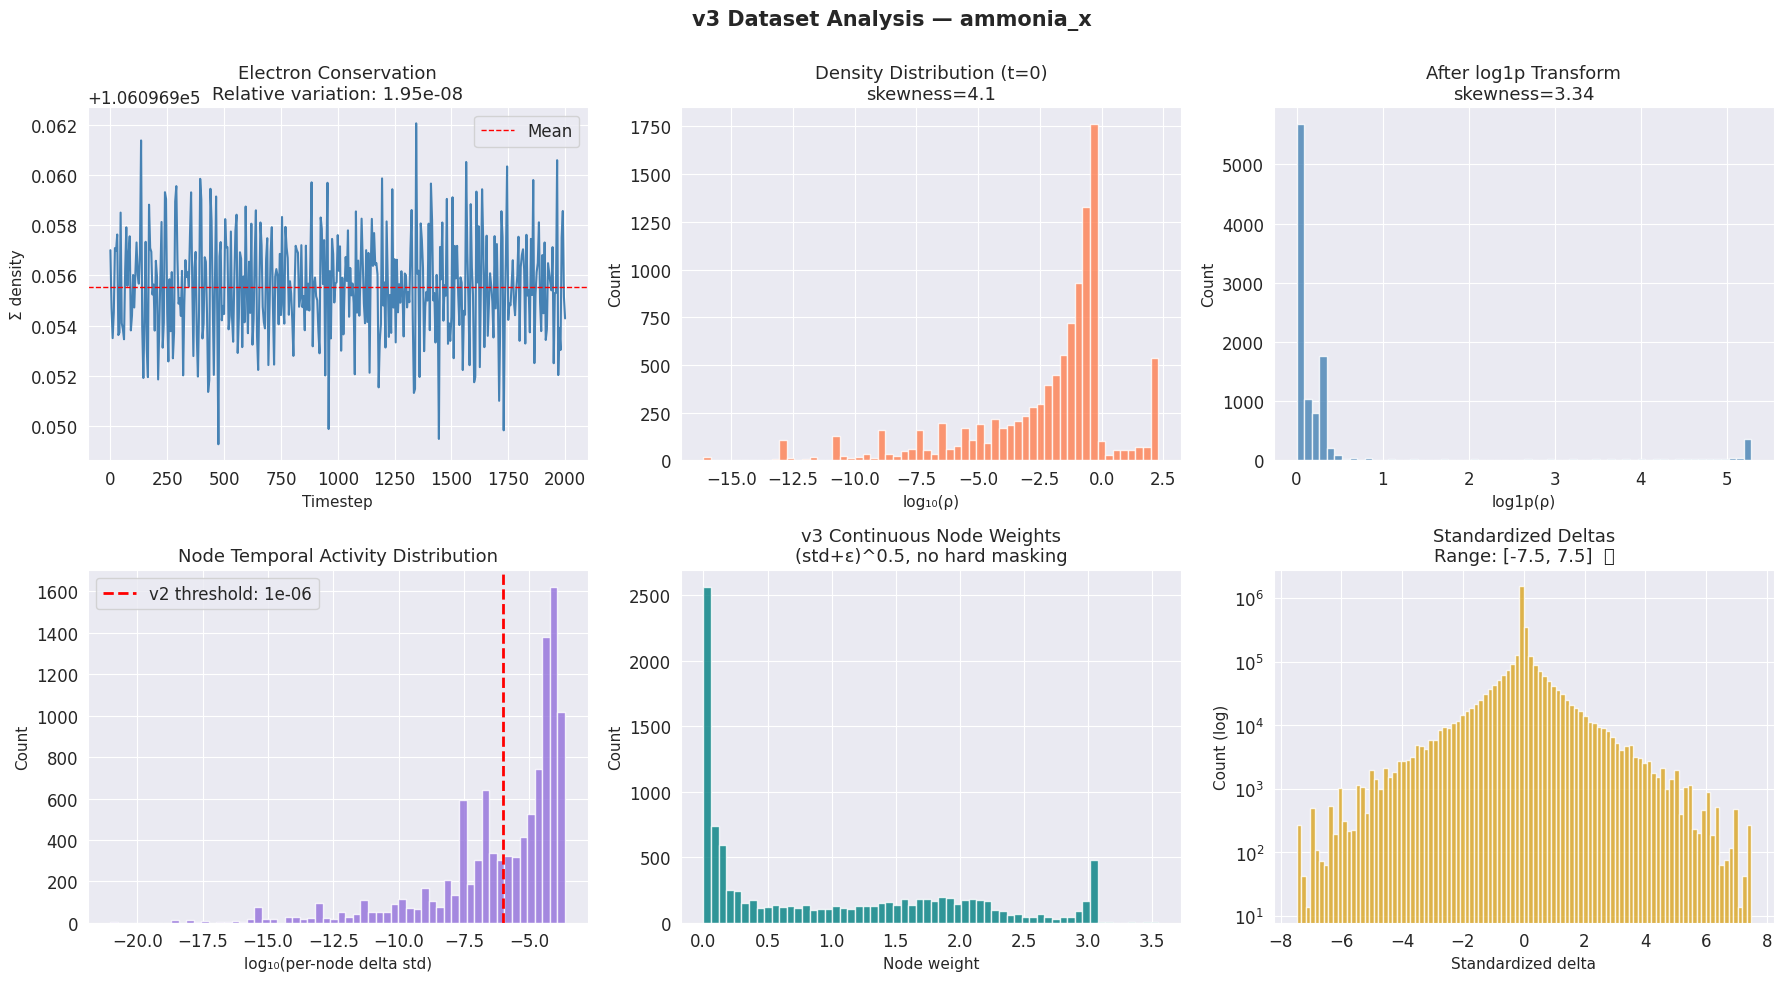

💾 Saved: reports/v3_dataset_insights.png


In [59]:
# ── VISUALIZATION ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'v3 Dataset Analysis — {DATASET_NAME}', fontsize=15, fontweight='bold')

# 1) Total electrons over time
total_electrons = all_raw.sum(axis=1)
rel_variation = total_electrons.std() / total_electrons.mean()
ax = axes[0, 0]
ax.plot(timestep_ids, total_electrons, 'steelblue', lw=1.5)
ax.axhline(total_electrons.mean(), color='red', ls='--', lw=1, label='Mean')
ax.set_xlabel('Timestep'); ax.set_ylabel('Σ density')
ax.set_title(f'Electron Conservation\nRelative variation: {rel_variation:.2e}')
ax.legend()

# 2) Raw density distribution
ax = axes[0, 1]
ax.hist(np.log10(np.clip(all_raw[0], 1e-20, None)), bins=60,
        color='coral', edgecolor='white', alpha=0.8)
ax.set_xlabel('log₁₀(ρ)'); ax.set_ylabel('Count')
ax.set_title(f'Density Distribution (t=0)\nskewness={stats.skew(all_raw[0]):.1f}')

# 3) log1p distribution
ax = axes[0, 2]
ax.hist(all_tf[0], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('log1p(ρ)'); ax.set_ylabel('Count')
ax.set_title(f'After log1p Transform\nskewness={stats.skew(all_tf[0]):.2f}')

# 4) Per-node temporal std
ax = axes[1, 0]
log_std = np.log10(np.clip(per_node_std, 1e-25, None))
ax.hist(log_std, bins=60, color='mediumpurple', edgecolor='white', alpha=0.8)
ax.axvline(np.log10(ACTIVE_THRESHOLD), color='red', ls='--', lw=2, label=f'v2 threshold: {ACTIVE_THRESHOLD:.0e}')
ax.set_xlabel('log₁₀(per-node delta std)'); ax.set_ylabel('Count')
ax.set_title('Node Temporal Activity Distribution')
ax.legend()

# 5) Continuous node weights (v3 improvement) — preview
ax = axes[1, 1]
cont_weights = (per_node_std + WEIGHT_EPS) ** WEIGHT_ALPHA
cont_weights /= cont_weights.mean()
ax.hist(cont_weights, bins=60, color='teal', edgecolor='white', alpha=0.8)
ax.set_xlabel('Node weight'); ax.set_ylabel('Count')
ax.set_title(f'v3 Continuous Node Weights\n(std+ε)^{WEIGHT_ALPHA}, no hard masking')

# 6) Scaled deltas
ax = axes[1, 2]
ax.hist(scaled_demo.flatten(), bins=100, color='goldenrod', edgecolor='white', alpha=0.8, log=True)
ax.set_xlabel('Standardized delta'); ax.set_ylabel('Count (log)')
ax.set_title(f'Standardized Deltas\nRange: [{scaled_demo.min():.1f}, {scaled_demo.max():.1f}]  ✅')

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'v3_dataset_insights.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: reports/v3_dataset_insights.png")

## 5. Graph Construction — v3 Edge Strategy

**v2 used:** Sequential (index-based, k=5) + kNN spatial (k=10)

**v3 uses:** Feature-similarity (cosine, k=8) + kNN spatial (k=10)

### Why remove sequential edges?
Sequential edges connect node i to nodes i±1, i±2, ... by grid index.
The grid index ordering is **arbitrary** — it's the order the quantum chemistry code wrote the file, not a physical relationship. These edges add noise to the message passing.

### Feature-similarity edges
We compute each node's **temporal density profile** across training timesteps → (N, T_train) matrix.
Then we connect each node to its **top-k most cosine-similar** nodes.
We ONLY consider active nodes (std > threshold) for meaningful cosine similarity.

### Edge-type encoding
Each edge gets a type label: 0 = spatial, 1 = feature-similarity, 2 = both.
This is encoded as a learnable embedding inside the model.

In [60]:
# ═══════════════════════════════════════════════════════════════
# 5. GRAPH CONSTRUCTION
# ═══════════════════════════════════════════════════════════════

def build_knn_spatial_edges(coords, k):
    """kNN edges in 3D physical space — captures local chemical environment."""
    nbrs = NearestNeighbors(n_neighbors=k + 1, algorithm='ball_tree').fit(coords)
    _, idx = nbrs.kneighbors(coords)
    src, dst = [], []
    for i in range(len(coords)):
        for j in idx[i, 1:]:   # skip self (index 0)
            src.extend([i, int(j)])
            dst.extend([int(j), i])
    return torch.unique(torch.tensor([src, dst], dtype=torch.long), dim=1)

def build_feature_similarity_edges(density_tf, train_end_ts, k, node_std, active_thresh, batch_size=1000):
    """
    Feature-similarity edges based on cosine similarity of temporal density profiles.
    Only considers ACTIVE nodes (std > threshold) — static nodes have near-zero profiles
    that produce meaningless cosine similarity.
    """
    profiles = density_tf[:train_end_ts].T   # (N, T_train) float64
    active_mask = node_std > active_thresh
    active_idx = np.where(active_mask)[0]
    N_active = len(active_idx)
    print(f"   Feature-sim: using {N_active} active nodes (excluding static from cosine sim)")

    active_profiles = profiles[active_idx]
    norms = np.linalg.norm(active_profiles, axis=1, keepdims=True) + 1e-12
    normed = active_profiles / norms

    src_all, dst_all = [], []
    for start in range(0, N_active, batch_size):
        end = min(start + batch_size, N_active)
        sim_batch = normed[start:end] @ normed.T
        for bi in range(end - start):
            sim_batch[bi, start + bi] = -2.0
        topk_local = np.argpartition(sim_batch, -k, axis=1)[:, -k:]
        for bi in range(end - start):
            global_i = active_idx[start + bi]
            for j_local in topk_local[bi]:
                global_j = active_idx[j_local]
                src_all.extend([int(global_i), int(global_j)])
                dst_all.extend([int(global_j), int(global_i)])

    return torch.unique(torch.tensor([src_all, dst_all], dtype=torch.long), dim=1)

print(f"🔗 Building v3 graph ({NUM_NODES} nodes)...")

# kNN spatial edges
print("   Building spatial kNN edges...")
t0 = time.time()
knn_edges = build_knn_spatial_edges(grid_coords, K_SPATIAL)
print(f"   Spatial kNN:  {knn_edges.shape[1]:,} edges  ({time.time()-t0:.1f}s)")

# Feature-similarity edges (from training timesteps only, active nodes only)
print("   Building feature-similarity edges (batched cosine sim)...")
t0 = time.time()
feat_edges = build_feature_similarity_edges(all_tf, train_ts_end, K_FEATURE,
                                            per_node_std, ACTIVE_THRESHOLD)
print(f"   Feature-sim:  {feat_edges.shape[1]:,} edges  ({time.time()-t0:.1f}s)")

# Combined edge index (deduplicated)
graph_edges = torch.unique(torch.cat([knn_edges, feat_edges], dim=1), dim=1)
print(f"   Combined:     {graph_edges.shape[1]:,} edges  (avg degree: {graph_edges.shape[1]/NUM_NODES:.1f})")

# Edge type labels: 0=spatial, 1=feature-similarity, 2=both
knn_set  = set(map(tuple, knn_edges.T.numpy()))
feat_set = set(map(tuple, feat_edges.T.numpy()))

edge_arr = graph_edges.T.numpy()
edge_types = []
for e in edge_arr:
    key = tuple(e)
    if key in feat_set and key in knn_set:
        edge_types.append(2)   # both
    elif key in feat_set:
        edge_types.append(1)   # feature-sim only
    else:
        edge_types.append(0)   # spatial only

EDGE_TYPES = torch.tensor(edge_types, dtype=torch.long)
print(f"   Edge types: {(EDGE_TYPES==0).sum()} spatial, "
      f"{(EDGE_TYPES==1).sum()} feat-sim, {(EDGE_TYPES==2).sum()} both")

# Spatial kNN edge index (kept separately for smoothness loss)
KNN_EDGE_INDEX = knn_edges

🔗 Building v3 graph (10540 nodes)...
   Building spatial kNN edges...
   Spatial kNN:  136,080 edges  (0.8s)
   Building feature-similarity edges (batched cosine sim)...
   Feature-sim: using 6411 active nodes (excluding static from cosine sim)
   Feature-sim:  65,496 edges  (0.7s)
   Combined:     163,280 edges  (avg degree: 15.5)
   Edge types: 97784 spatial, 27200 feat-sim, 38296 both


In [61]:
# ═══════════════════════════════════════════════════════════════
# 6. CONTINUOUS NODE WEIGHTS & NORMALIZATION
# ═══════════════════════════════════════════════════════════════
#
# v2: weight=0 for static, weight=sqrt(std) for active (hard binary)
# v3: weight=(std+eps)^alpha for ALL nodes (continuous)
#   → static nodes get tiny but nonzero weight
#   → normalization: mean weight = 1 over ACTIVE nodes (matching v2 scale)

active_mask_v2 = per_node_std > ACTIVE_THRESHOLD
N_ACTIVE = active_mask_v2.sum()
N_STATIC = (~active_mask_v2).sum()

node_weights_np = (per_node_std + WEIGHT_EPS) ** WEIGHT_ALPHA   # (N,) float64

# Normalize so mean weight OVER ACTIVE nodes = 1.0
active_mean = node_weights_np[active_mask_v2].mean()
node_weights_np /= active_mean
node_weights_np = node_weights_np.astype(np.float32)

NODE_WEIGHTS_TENSOR = torch.tensor(node_weights_np, dtype=torch.float32)

print("📊 v3 Node Weights (continuous, no hard masking):")
print(f"   Weight formula: (per_node_std + {WEIGHT_EPS:.0e})^{WEIGHT_ALPHA}")
print(f"   Normalization: mean weight = 1.0 over ACTIVE nodes")
print(f"   Weight range (all):    [{node_weights_np.min():.6f}, {node_weights_np.max():.4f}]")
print(f"   Weight mean (active):  {node_weights_np[active_mask_v2].mean():.4f}")
print(f"   Weight mean (static):  {node_weights_np[~active_mask_v2].mean():.8f}  ← very small")
print(f"   Active nodes (std>{ACTIVE_THRESHOLD}):  {N_ACTIVE} ({N_ACTIVE/NUM_NODES*100:.1f}%)")
print(f"   Static nodes (std≤{ACTIVE_THRESHOLD}): {N_STATIC} ({N_STATIC/NUM_NODES*100:.1f}%)")
print(f"   Total weight from active: {node_weights_np[active_mask_v2].sum():.1f}")
print(f"   Total weight from static: {node_weights_np[~active_mask_v2].sum():.4f}  ← negligible")
print(f"   ✅ Active nodes dominate gradient (~{node_weights_np[active_mask_v2].sum() / node_weights_np.sum() * 100:.1f}%)")

# Normalized spatial coords (for node features)
coord_min = grid_coords.min(axis=0)
coord_max = grid_coords.max(axis=0)
coord_range = (coord_max - coord_min) + 1e-12
COORDS_NORM = ((grid_coords - coord_min) / coord_range).astype(np.float32)   # (N,3) in [0,1]
COORDS_TENSOR = torch.tensor(COORDS_NORM, dtype=torch.float32)
print(f"\n📐 Normalized spatial coordinates: shape={COORDS_NORM.shape}, range [0,1]")

📊 v3 Node Weights (continuous, no hard masking):
   Weight formula: (per_node_std + 1e-12)^0.5
   Normalization: mean weight = 1.0 over ACTIVE nodes
   Weight range (all):    [0.000144, 2.2072]
   Weight mean (active):  1.0000
   Weight mean (static):  0.03619561  ← very small
   Active nodes (std>1e-06):  6411 (60.8%)
   Static nodes (std≤1e-06): 4129 (39.2%)
   Total weight from active: 6411.0
   Total weight from static: 149.4517  ← negligible
   ✅ Active nodes dominate gradient (~97.7%)

📐 Normalized spatial coordinates: shape=(10540, 3), range [0,1]


## 7. Dataset

### v3 Node Features: density history + spatial coordinates
```
x[node] = [log1p(ρ(t-4)), log1p(ρ(t-3)), log1p(ρ(t-2)), log1p(ρ(t-1)), log1p(ρ(t)), x_norm, y_norm, z_norm]
           └─────────────────── 5 temporal features ──────────────────────┘  └── 3 spatial ──┘
```
This tells the model **both** the temporal history and the spatial location of each node.

### Target: standardized delta (same as v2)
```
z = (Δρ - μ_train) / σ_train    → range ≈ [-7, 7]
```

In [62]:
# ═══════════════════════════════════════════════════════════════
# 7. DATASET (density+xyz features, standardized delta target)
# ═══════════════════════════════════════════════════════════════

class DensityDatasetV3(Dataset):
    """
    v3 Dataset:
      - Node features = [lookback density values, x_norm, y_norm, z_norm]
      - Target = standardized delta (z-scored)
    """
    def __init__(self, density_tf, coords_norm, edge_index, edge_types,
                 node_weights, lookback, lookahead, delta_mean, delta_std):
        super().__init__()
        self.tf        = density_tf
        self.coords    = coords_norm
        self.edges     = edge_index
        self.etypes    = edge_types
        self.w         = node_weights
        self.lb        = lookback
        self.la        = lookahead
        self.mu        = delta_mean
        self.sigma     = delta_std
        self.n         = len(density_tf) - lookback - lookahead + 1

    def len(self): return self.n

    def get(self, idx):
        dens_feats = torch.tensor(self.tf[idx:idx+self.lb].T, dtype=torch.float32)
        x = torch.cat([dens_feats, self.coords], dim=1)

        last_i   = idx + self.lb - 1
        target_i = idx + self.lb + self.la - 1

        raw_delta = (self.tf[target_i] - self.tf[last_i])
        std_delta = ((raw_delta - self.mu) / self.sigma).astype(np.float32)

        return Data(
            x            = x,
            edge_index   = self.edges,
            edge_type    = self.etypes,
            y            = torch.tensor(std_delta),
            node_weights = self.w,
            last_input   = torch.tensor(self.tf[last_i],   dtype=torch.float32),
            abs_target   = torch.tensor(self.tf[target_i], dtype=torch.float32),
            raw_delta    = torch.tensor(raw_delta.astype(np.float32)),
            ts_idx       = torch.tensor(idx),
        )

dataset = DensityDatasetV3(
    all_tf, COORDS_TENSOR, graph_edges, EDGE_TYPES,
    NODE_WEIGHTS_TENSOR, LOOKBACK, LOOKAHEAD, DELTA_MEAN, DELTA_STD
)

sample = dataset[0]
print(f"📦 Dataset: {len(dataset)} samples")
print(f"   x shape: {sample.x.shape}  ({LOOKBACK} temporal + 3 spatial features)")
print(f"   y range: [{sample.y.min():.2f}, {sample.y.max():.2f}]  ✅ standardized delta")
print(f"   edge_index: {sample.edge_index.shape}")
print(f"   edge_type:  {sample.edge_type.shape}  (0=spatial, 1=feat, 2=both)")

📦 Dataset: 396 samples
   x shape: torch.Size([10540, 8])  (5 temporal + 3 spatial features)
   y range: [-4.12, 4.12]  ✅ standardized delta
   edge_index: torch.Size([2, 163280])
   edge_type:  torch.Size([163280])  (0=spatial, 1=feat, 2=both)


In [63]:
# ═══════════════════════════════════════════════════════════════
# 8. CHRONOLOGICAL SPLIT
# ═══════════════════════════════════════════════════════════════
n    = len(dataset)
n_tr = int(TRAIN_RATIO * n)
n_va = int(VAL_RATIO   * n)
n_te = n - n_tr - n_va

train_ds = [dataset[i] for i in range(n_tr)]
val_ds   = [dataset[i] for i in range(n_tr, n_tr+n_va)]
test_ds  = [dataset[i] for i in range(n_tr+n_va, n)]

nw  = min(4, os.cpu_count() or 1)
pin = torch.cuda.is_available()
kw  = dict(num_workers=nw, pin_memory=pin, persistent_workers=nw>0)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **kw)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **kw)

print(f"📊 Split (chronological — no shuffle):")
print(f"   Train {TRAIN_RATIO:.0%}: {n_tr} samples")
print(f"   Val   {VAL_RATIO:.0%}:  {n_va} samples")
print(f"   Test  {TEST_RATIO:.0%}:  {n_te} samples")

📊 Split (chronological — no shuffle):
   Train 80%: 316 samples
   Val   10%:  39 samples
   Test  10%:  41 samples


## 8. Model: TemporalGATv3

### Key changes from v2:
1. **Edge-type embedding** — learnable embedding per edge type (spatial / feature-sim / both), modulates node features before each GAT layer
2. **Input dim** = LOOKBACK + 3 (5 density + x,y,z)

```
Input (N, 8) → Project(8→128) ──[edge-type modulation]──
    → 4× [GATConv + LayerNorm + GELU + Residual]
    → OutputHead(128→64→32→1)
    → Predicted Δρ per node: shape (N,)
```

In [64]:
# ═══════════════════════════════════════════════════════════════
# 9. MODEL (TemporalGATv3)
# ═══════════════════════════════════════════════════════════════

class EdgeTypeEmbedding(nn.Module):
    """Encodes edge type into a bias added to node features before GAT."""
    def __init__(self, n_types, hidden):
        super().__init__()
        self.emb = nn.Embedding(n_types, hidden)
        nn.init.normal_(self.emb.weight, std=0.01)

    def forward(self, edge_type, num_nodes, edge_index):
        e = self.emb(edge_type)
        dst = edge_index[1]
        out = torch.zeros(num_nodes, e.size(1), dtype=e.dtype, device=e.device)
        out.scatter_add_(0, dst.unsqueeze(1).expand_as(e), e)
        return out

class TemporalGATv3(nn.Module):
    """
    v3: 4-layer GAT with edge-type embedding.
    No conservation projection — direct prediction of standardized deltas.
    """
    def __init__(self, input_dim, hidden=128, n_layers=4, heads=4, dropout=0.10):
        super().__init__()
        self.drop = dropout

        self.proj = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.etype_embs = nn.ModuleList([
            EdgeTypeEmbedding(3, hidden) for _ in range(n_layers)
        ])

        self.gats  = nn.ModuleList()
        self.norms = nn.ModuleList()
        for i in range(n_layers):
            last   = (i == n_layers - 1)
            out_ch = hidden // heads if not last else hidden
            self.gats.append(GATConv(
                hidden, out_ch,
                heads=heads if not last else 1,
                concat=not last,
                dropout=dropout,
                add_self_loops=True,
            ))
            self.norms.append(nn.LayerNorm(hidden))

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden // 2, hidden // 4), nn.GELU(),
            nn.Linear(hidden // 4, 1),
        )

    def forward(self, data, return_attn=False):
        x, ei = data.x, data.edge_index
        et    = data.edge_type if hasattr(data, 'edge_type') else None
        N     = x.size(0)

        x = self.proj(x)
        last_a = None

        for i, (gat, norm, etype_emb) in enumerate(zip(self.gats, self.norms, self.etype_embs)):
            xr = x
            if et is not None:
                x = x + etype_emb(et, N, ei)

            if return_attn:
                x, last_a = gat(x, ei, return_attention_weights=True)
            else:
                x = gat(x, ei)

            x = norm(x)
            x = F.gelu(x)
            x = F.dropout(x, p=self.drop, training=self.training)
            if x.shape == xr.shape:
                x = x + xr

        out = self.head(x).squeeze(-1)   # (N,) direct prediction

        if return_attn:
            return out, last_a
        return out

model = TemporalGATv3(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS, NUM_HEADS, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"🏗️  TemporalGATv3: {n_params:,} parameters")
print(f"   Input:  ({NUM_NODES}, {INPUT_DIM}) = {LOOKBACK} density + 3 xyz")
print(f"   Output: ({NUM_NODES},) standardized delta")

🏗️  TemporalGATv3: 81,409 parameters
   Input:  (10540, 8) = 5 density + 3 xyz
   Output: (10540,) standardized delta


## 9. Loss Function

```
L_total = L_wmse + λ_s · L_smooth
```

### L_wmse — Continuous Variance-Weighted MSE
All nodes contribute with continuous weights based on temporal activity.

### L_smooth — Spatial Smoothness (after warmup)
Penalizes large prediction differences between spatial neighbors.
Disabled for first {WARMUP_EPOCHS} epochs to let model learn freely.

In [65]:
# ═══════════════════════════════════════════════════════════════
# 10. LOSS FUNCTIONS
# ═══════════════════════════════════════════════════════════════

class ContinuousWeightedMSE(nn.Module):
    """MSE weighted by continuous per-node temporal activity."""
    def forward(self, pred, target, weights):
        sq = (pred - target) ** 2
        return (sq * weights).sum() / weights.sum().clamp(min=1.0)

class SpatialSmoothnessLoss(nn.Module):
    """Penalize large delta differences between spatially close nodes."""
    def __init__(self, knn_edge_index, coords, num_nodes):
        super().__init__()
        src = knn_edge_index[0].numpy()
        dst = knn_edge_index[1].numpy()
        dists = np.linalg.norm(coords[src] - coords[dst], axis=1) + 1e-12
        inv_dist = (1.0 / dists).astype(np.float32)
        inv_dist /= inv_dist.mean()
        self.register_buffer('knn_ei',    knn_edge_index)
        self.register_buffer('inv_dist',  torch.tensor(inv_dist))
        self.num_nodes = num_nodes

    def forward(self, pred, batch=None):
        if batch is None:
            src, dst = self.knn_ei[0], self.knn_ei[1]
            diff = (pred[src] - pred[dst]) ** 2
            return (diff * self.inv_dist).mean()
        else:
            n_graphs = int(batch.max().item()) + 1
            loss = torch.tensor(0.0, device=pred.device, dtype=pred.dtype)
            for g in range(n_graphs):
                mask = (batch == g)
                pred_g = pred[mask]
                src, dst = self.knn_ei[0], self.knn_ei[1]
                diff = (pred_g[src] - pred_g[dst]) ** 2
                loss = loss + (diff * self.inv_dist).mean()
            return loss / n_graphs

smooth_loss_fn = SpatialSmoothnessLoss(KNN_EDGE_INDEX, grid_coords, NUM_NODES).to(device)
wmse_fn = ContinuousWeightedMSE()

def total_loss(pred, target, weights, batch, epoch,
               lambda_smooth=LAMBDA_SMOOTH, warmup=WARMUP_EPOCHS):
    """
    Combined loss with warmup schedule.
    During warmup: only weighted MSE.
    After warmup:  weighted MSE + smoothness regularization.
    """
    l_wmse = wmse_fn(pred, target, weights)

    if epoch > warmup:
        l_smooth = smooth_loss_fn(pred, batch)
        return l_wmse + lambda_smooth * l_smooth, l_wmse, l_smooth
    else:
        zero = torch.tensor(0.0, device=pred.device)
        return l_wmse, l_wmse, zero

print("✅ Loss set up:")
print(f"   L_total = L_wmse + {LAMBDA_SMOOTH} × L_smooth")
print(f"   Warmup: smoothness OFF for first {WARMUP_EPOCHS} epochs")
print(f"   L_wmse:   continuous weighted MSE (all nodes, weight=(std+ε)^{WEIGHT_ALPHA})")
print(f"   L_smooth: spatial smoothness on kNN edges (inv-distance weighted)")

✅ Loss set up:
   L_total = L_wmse + 0.001 × L_smooth
   Warmup: smoothness OFF for first 15 epochs
   L_wmse:   continuous weighted MSE (all nodes, weight=(std+ε)^0.5)
   L_smooth: spatial smoothness on kNN edges (inv-distance weighted)


In [66]:
# ═══════════════════════════════════════════════════════════════
# 11. TRAINING LOOP
# ═══════════════════════════════════════════════════════════════
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=20, T_mult=2, eta_min=1e-6)

use_amp   = torch.cuda.is_available()
scaler    = torch.cuda.amp.GradScaler(enabled=use_amp)

def train_epoch(model, loader, opt, device, scaler, amp, epoch):
    model.train()
    tot, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=amp):
            pred = model(batch)
            loss, lw, ls = total_loss(
                pred, batch.y, batch.node_weights, batch.batch, epoch)
        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(opt); scaler.update()
        tot += loss.item() * batch.num_graphs
        n   += batch.num_graphs
    return tot / n

@torch.no_grad()
def eval_epoch(model, loader, device, amp, epoch):
    model.eval()
    tot, n = 0.0, 0
    for batch in loader:
        batch = batch.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=amp):
            pred = model(batch)
            loss, _, _ = total_loss(
                pred, batch.y, batch.node_weights, batch.batch, epoch)
        tot += loss.item() * batch.num_graphs
        n   += batch.num_graphs
    return tot / n

best_path = str(MODEL_DIR / f"best_gat_v3_{DATASET_NAME}_lb{LOOKBACK}.pt")
train_l, val_l = [], []
best_val, no_imp = float('inf'), 0

print("🚀 Training TemporalGATv3")
print(f"   Features: {INPUT_DIM}D (density+xyz) | Edges: spatial+feature-sim")
print(f"   Loss: weighted-MSE + smoothness (warmup: {WARMUP_EPOCHS} eps)")
print("-" * 90)
t0 = time.time()

for ep in range(1, EPOCHS + 1):
    te  = time.time()
    tl  = train_epoch(model, train_loader, optimizer, device, scaler, use_amp, ep)
    vl  = eval_epoch(model, val_loader, device, use_amp, ep)
    scheduler.step(ep)
    train_l.append(tl); val_l.append(vl)

    improved = vl < best_val
    if improved:
        best_val = vl; no_imp = 0
        torch.save(model.state_dict(), best_path)
    else:
        no_imp += 1

    lr_now = optimizer.param_groups[0]['lr']
    if ep % 5 == 0 or ep <= 3 or improved or ep == WARMUP_EPOCHS + 1:
        mark = "  ⬇ BEST" if improved else ""
        phase = "WARMUP" if ep <= WARMUP_EPOCHS else "FULL"
        print(f"  Ep {ep:3d}/{EPOCHS} [{phase:6s}] | Train: {tl:.5f} | Val: {vl:.5f} | "
              f"LR: {lr_now:.1e} | {time.time()-te:.1f}s{mark}")

    if no_imp >= PATIENCE:
        print(f"\n⛔ Early stopping at epoch {ep}")
        break

tot = time.time() - t0
print(f"\n✅ Done: {len(train_l)} epochs in {tot:.0f}s ({tot/60:.1f} min)")
print(f"   Best val loss: {best_val:.6f}  |  Model: {best_path}")

🚀 Training TemporalGATv3
   Features: 8D (density+xyz) | Edges: spatial+feature-sim
   Loss: weighted-MSE + smoothness (warmup: 15 eps)
------------------------------------------------------------------------------------------
  Ep   1/120 [WARMUP] | Train: 2.60295 | Val: 2.76410 | LR: 5.0e-04 | 6.9s  ⬇ BEST
  Ep   2/120 [WARMUP] | Train: 2.60084 | Val: 2.76408 | LR: 4.9e-04 | 6.8s  ⬇ BEST
  Ep   3/120 [WARMUP] | Train: 2.60083 | Val: 2.76409 | LR: 4.7e-04 | 6.8s
  Ep   5/120 [WARMUP] | Train: 2.60072 | Val: 2.76408 | LR: 4.3e-04 | 6.9s  ⬇ BEST
  Ep   7/120 [WARMUP] | Train: 2.60070 | Val: 2.76408 | LR: 3.6e-04 | 7.0s  ⬇ BEST
  Ep  10/120 [WARMUP] | Train: 2.60070 | Val: 2.76408 | LR: 2.5e-04 | 7.1s
  Ep  13/120 [WARMUP] | Train: 2.60070 | Val: 2.76408 | LR: 1.4e-04 | 8.4s  ⬇ BEST
  Ep  15/120 [WARMUP] | Train: 2.60068 | Val: 2.76408 | LR: 7.4e-05 | 7.2s  ⬇ BEST
  Ep  16/120 [FULL  ] | Train: 2.60068 | Val: 2.76408 | LR: 4.9e-05 | 7.4s
  Ep  20/120 [FULL  ] | Train: 2.60068 | Val: 2.76

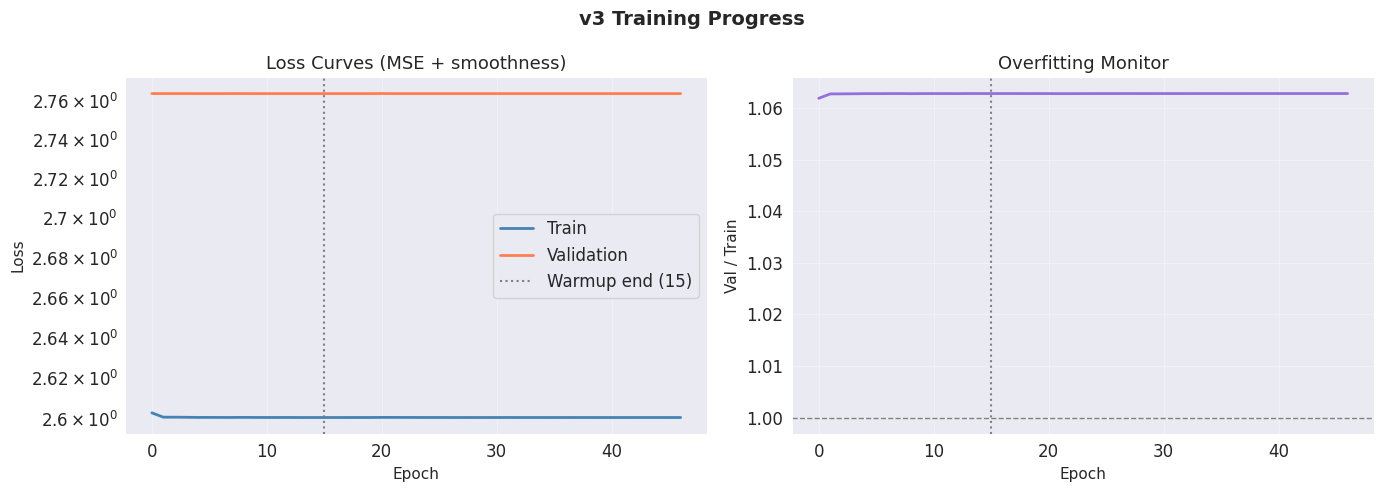

💾 Saved: reports/v3_training_curves.png


In [67]:
# ─── TRAINING CURVES ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('v3 Training Progress', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(train_l, label='Train',      color='steelblue', lw=2)
ax.plot(val_l,   label='Validation', color='coral',     lw=2)
ax.axvline(WARMUP_EPOCHS, color='gray', ls=':', lw=1.5, label=f'Warmup end ({WARMUP_EPOCHS})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Loss Curves (MSE + smoothness)')
ax.legend(); ax.set_yscale('log'); ax.grid(alpha=0.3)

ax = axes[1]
ratio = np.array(val_l) / (np.array(train_l) + 1e-20)
ax.plot(ratio, color='mediumpurple', lw=2)
ax.axhline(1.0, color='gray', ls='--', lw=1)
ax.axvline(WARMUP_EPOCHS, color='gray', ls=':', lw=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Val / Train')
ax.set_title('Overfitting Monitor'); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'v3_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: reports/v3_training_curves.png")

## 10. Evaluation

Load best checkpoint, run test set, unscale predictions, compute comprehensive metrics.

In [68]:
# ═══════════════════════════════════════════════════════════════
# 12. COLLECT TEST PREDICTIONS
# ═══════════════════════════════════════════════════════════════
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

buf = {'pred_z':[], 'true_z':[], 'raw_delta':[], 'last_in':[],
       'abs_tgt':[], 'w':[]}

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            pred = model(batch)
        buf['pred_z'].append(pred.cpu().numpy())
        buf['true_z'].append(batch.y.cpu().numpy())
        buf['raw_delta'].append(batch.raw_delta.cpu().numpy())
        buf['last_in'].append(batch.last_input.cpu().numpy())
        buf['abs_tgt'].append(batch.abs_target.cpu().numpy())
        buf['w'].append(batch.node_weights.cpu().numpy())

pred_z    = np.concatenate(buf['pred_z'])
true_z    = np.concatenate(buf['true_z'])
raw_true  = np.concatenate(buf['raw_delta'])
last_in   = np.concatenate(buf['last_in'])
abs_tgt   = np.concatenate(buf['abs_tgt'])
w_all     = np.concatenate(buf['w'])

# Unscale predictions
pred_delta  = pred_z.astype(np.float64) * DELTA_STD + DELTA_MEAN
pred_logtf  = last_in.astype(np.float64) + pred_delta
true_logtf  = abs_tgt.astype(np.float64)
pred_orig   = np.expm1(pred_logtf)
true_orig   = np.expm1(true_logtf)
base_orig   = np.expm1(last_in.astype(np.float64))

# Active nodes (for reference comparison with v2)
active_test = per_node_std[np.tile(np.arange(NUM_NODES), len(test_ds))] > ACTIVE_THRESHOLD

print(f"📊 Test predictions: {len(pred_z):,} total")
print(f"   Active nodes (std>{ACTIVE_THRESHOLD}): {active_test.sum():,} ({active_test.mean()*100:.1f}%)")
print(f"   pred_z range: [{pred_z.min():.2f}, {pred_z.max():.2f}]")

📊 Test predictions: 432,140 total
   Active nodes (std>1e-06): 262,851 (60.8%)
   pred_z range: [-0.01, 0.00]


In [69]:
# ═══════════════════════════════════════════════════════════════
# 12a. COMPREHENSIVE METRICS
# ═══════════════════════════════════════════════════════════════
def compute_metrics(pred, true, mask=None):
    if mask is not None:
        pred, true = pred[mask], true[mask]
    res  = pred - true
    mse  = float(np.mean(res**2))
    rmse = float(np.sqrt(mse))
    mae  = float(np.mean(np.abs(res)))
    rng  = float(np.ptp(true))
    nrmse= rmse / rng * 100 if rng > 0 else 0.0
    ss_r = np.sum(res**2); ss_t = np.sum((true - true.mean())**2)
    r2   = float(1 - ss_r/ss_t) if ss_t > 0 else 0.0
    nz   = np.abs(true) > 1e-10
    mape = float(np.mean(np.abs(res[nz]/true[nz]))*100) if nz.sum() else float('nan')
    n_p  = np.linalg.norm(pred.flatten()); n_t = np.linalg.norm(true.flatten())
    cos  = float(np.dot(pred.flatten(), true.flatten()) / (n_p * n_t + 1e-20))
    pr   = float(stats.pearsonr(pred.flatten(), true.flatten())[0]) if len(pred) > 1 else 0.0
    within = {}
    for t in [0.1, 0.5, 1.0, 5.0]:
        within[t] = float((np.abs(res[nz]/true[nz])*100 < t).mean()*100) if nz.sum() else 0.0
    return dict(MSE=mse, RMSE=rmse, MAE=mae, NRMSE_pct=nrmse, R2=r2,
                MAPE_pct=mape, Cosine_Sim=cos, Pearson_r=pr,
                **{f'Within_{k}pct': v for k, v in within.items()})

m = {
    'scaled_model':    compute_metrics(pred_z,                    true_z),
    'scaled_baseline': compute_metrics(np.zeros_like(true_z),     true_z),
    'delta_all_model': compute_metrics(pred_delta,                raw_true.astype(np.float64)),
    'delta_all_base':  compute_metrics(np.zeros_like(pred_delta), raw_true.astype(np.float64)),
    'delta_act_model': compute_metrics(pred_delta,                raw_true.astype(np.float64), active_test),
    'delta_act_base':  compute_metrics(np.zeros_like(pred_delta), raw_true.astype(np.float64), active_test),
    'abs_all_model':   compute_metrics(pred_orig,                 true_orig),
    'abs_all_base':    compute_metrics(base_orig,                 true_orig),
    'abs_act_model':   compute_metrics(pred_orig,                 true_orig, active_test),
    'abs_act_base':    compute_metrics(base_orig,                 true_orig, active_test),
}

W = 90
print("=" * W)
print("📊 v3 FINAL TEST METRICS")
print("=" * W)

sections = [
    ("A  Scaled-delta space (model output)",    'scaled_model',    'scaled_baseline'),
    ("B  Raw delta — ALL nodes",                'delta_all_model', 'delta_all_base'),
    ("C  Raw delta — ACTIVE nodes ★",           'delta_act_model', 'delta_act_base'),
    ("D  Absolute density — ALL nodes",         'abs_all_model',   'abs_all_base'),
    ("E  Absolute density — ACTIVE nodes ★",    'abs_act_model',   'abs_act_base'),
]
for title, mk, bk in sections:
    print(f"\n{'─'*W}")
    print(f"  {title}")
    print(f"  {'Metric':<22} {'Model':>14} {'Baseline':>14} {'Winner':>10}")
    print(f"  {'─'*22} {'─'*14} {'─'*14} {'─'*10}")
    for key in ['R2', 'MAE', 'RMSE', 'NRMSE_pct', 'MAPE_pct', 'Cosine_Sim', 'Pearson_r']:
        if key not in m[mk]: continue
        mv, bv = m[mk][key], m[bk][key]
        win = "Model ✅" if (mv > bv if key in ('R2','Cosine_Sim','Pearson_r') else mv < bv) else "Baseline ←"
        print(f"  {key:<22} {mv:>14.6f} {bv:>14.6f} {win:>10}")
    for t in [0.1, 0.5, 1.0, 5.0]:
        k = f'Within_{t}pct'
        if k in m[mk]:
            mv, bv = m[mk][k], m[bk][k]
            print(f"  {k:<22} {mv:>13.2f}% {bv:>13.2f}% {'Model ✅' if mv>bv else 'Baseline ←':>10}")

print(f"\n{'─'*W}")
print("  IMPROVEMENT SUMMARY")
print(f"  {'─'*W}")
for title, mk, bk in sections:
    mi = (1 - m[mk]['MAE'] / m[bk]['MAE']) * 100 if m[bk]['MAE'] > 0 else 0
    dr = m[mk]['R2'] - m[bk]['R2']
    print(f"  {title[:50]:<50} MAE: {mi:+.2f}%   ΔR²: {dr:+.6f}")

📊 v3 FINAL TEST METRICS

──────────────────────────────────────────────────────────────────────────────────────────
  A  Scaled-delta space (model output)
  Metric                          Model       Baseline     Winner
  ────────────────────── ────────────── ────────────── ──────────
  R2                          -0.000009      -0.000000 Baseline ←
  MAE                          0.499890       0.499262 Baseline ←
  RMSE                         1.035675       1.035670 Baseline ←
  NRMSE_pct                    7.315282       7.315252 Baseline ←
  MAPE_pct                 41450.378418     100.000000 Baseline ←
  Cosine_Sim                  -0.000850       0.000000 Baseline ←
  Pearson_r                   -0.000871            nan Baseline ←
  Within_0.1pct                   0.00%          0.00%    Model ✅
  Within_0.5pct                   0.02%          0.00%    Model ✅
  Within_1.0pct                   0.04%          0.00%    Model ✅
  Within_5.0pct                   0.21%          0.00

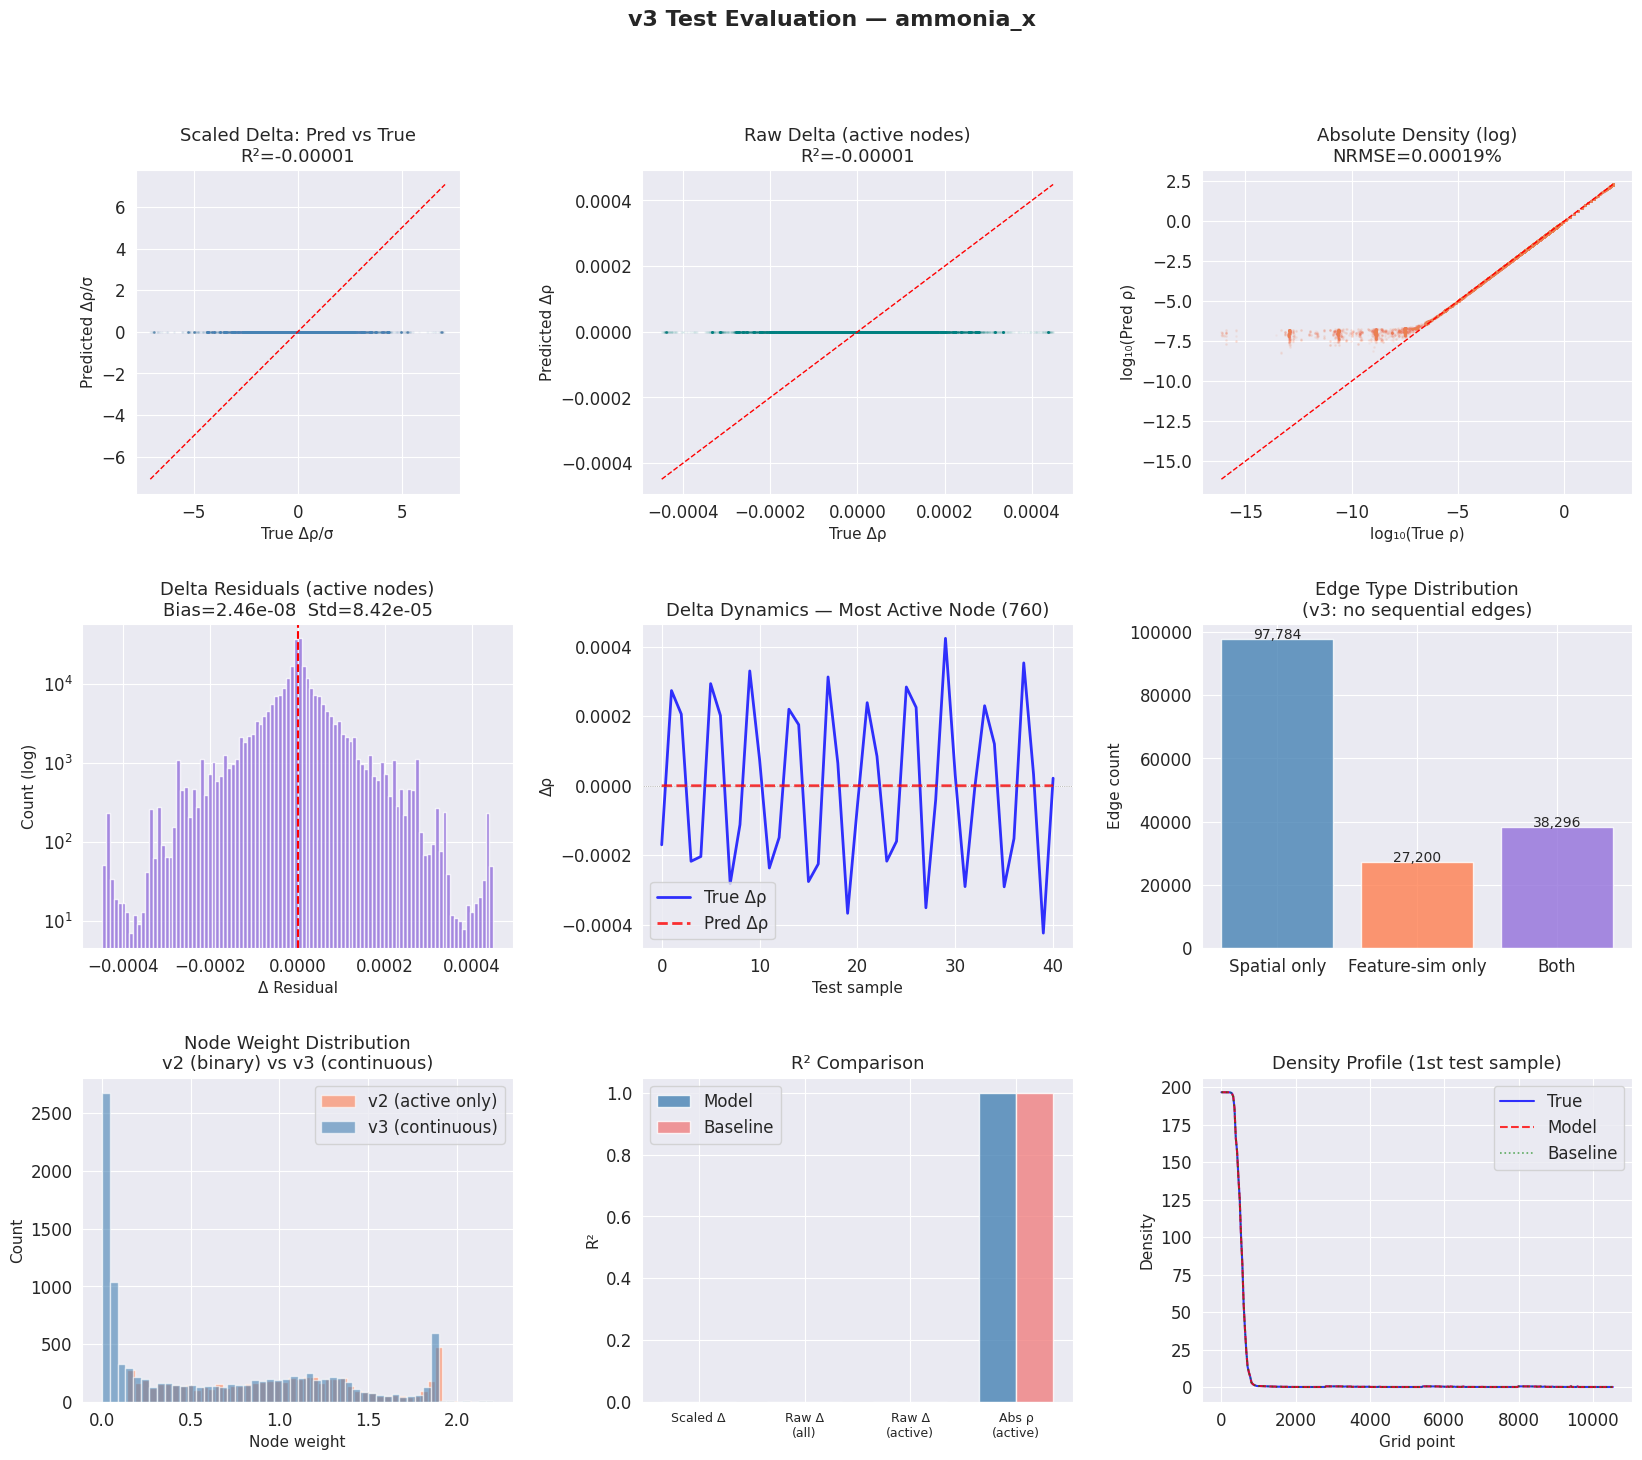

💾 Saved: reports/v3_test_evaluation.png


In [70]:
# ═══════════════════════════════════════════════════════════════
# 13. VISUALIZATIONS
# ═══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 16))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.40, wspace=0.30)
fig.suptitle(f'v3 Test Evaluation — {DATASET_NAME}', fontsize=16, fontweight='bold')

NP   = 50_000
ridx = np.random.choice(len(pred_z), min(NP, len(pred_z)), replace=False)

# 1) Scaled delta: pred vs true
ax = fig.add_subplot(gs[0, 0])
ax.scatter(true_z[ridx], pred_z[ridx], alpha=0.03, s=1, c='steelblue')
lim = max(np.abs(true_z[ridx]).max(), np.abs(pred_z[ridx]).max())
ax.plot([-lim,lim],[-lim,lim],'r--',lw=1); ax.set_aspect('equal')
ax.set_xlabel('True Δρ/σ'); ax.set_ylabel('Predicted Δρ/σ')
ax.set_title(f'Scaled Delta: Pred vs True\nR²={m["scaled_model"]["R2"]:.5f}')

# 2) Raw delta — active nodes
ax = fig.add_subplot(gs[0, 1])
ai  = np.where(active_test)[0]
sai = ai[np.random.choice(len(ai), min(NP,len(ai)), replace=False)]
ax.scatter(raw_true[sai], pred_delta[sai], alpha=0.04, s=1, c='teal')
lim = max(np.abs(raw_true[sai]).max(), np.abs(pred_delta[sai]).max())
ax.plot([-lim,lim],[-lim,lim],'r--',lw=1)
ax.set_xlabel('True Δρ'); ax.set_ylabel('Predicted Δρ')
ax.set_title(f'Raw Delta (active nodes)\nR²={m["delta_act_model"]["R2"]:.5f}')

# 3) Absolute density (log scale)
ax = fig.add_subplot(gs[0, 2])
lt = np.log10(np.clip(true_orig[ridx],1e-20,None))
lp = np.log10(np.clip(pred_orig[ridx],1e-20,None))
ax.scatter(lt, lp, alpha=0.02, s=1, c='coral')
ax.plot([lt.min(),lt.max()],[lt.min(),lt.max()],'r--',lw=1)
ax.set_xlabel('log₁₀(True ρ)'); ax.set_ylabel('log₁₀(Pred ρ)')
ax.set_title(f'Absolute Density (log)\nNRMSE={m["abs_all_model"]["NRMSE_pct"]:.5f}%')

# 4) Residual distribution (active)
ax = fig.add_subplot(gs[1, 0])
resid = (pred_delta - raw_true.astype(np.float64))[active_test]
ax.hist(resid, bins=100, color='mediumpurple', edgecolor='white', alpha=0.8, log=True)
ax.axvline(0, color='red', ls='--')
ax.set_xlabel('Δ Residual'); ax.set_ylabel('Count (log)')
ax.set_title(f'Delta Residuals (active nodes)\nBias={resid.mean():.2e}  Std={resid.std():.2e}')

# 5) Most active node: delta over time
ax = fig.add_subplot(gs[1, 1])
top_node = np.argsort(per_node_std)[-1]
n_test_s = len(test_ds)
pred_node = pred_delta.reshape(n_test_s, NUM_NODES)[:, top_node]
true_node = raw_true.reshape(n_test_s, NUM_NODES)[:, top_node]
ax.plot(true_node, 'b-', lw=2, alpha=0.8, label='True Δρ')
ax.plot(pred_node, 'r--', lw=2, alpha=0.8, label='Pred Δρ')
ax.axhline(0, color='gray', ls=':', lw=0.5)
ax.set_xlabel('Test sample'); ax.set_ylabel('Δρ')
ax.set_title(f'Delta Dynamics — Most Active Node ({top_node})'); ax.legend()

# 6) Edge type distribution
ax = fig.add_subplot(gs[1, 2])
et = EDGE_TYPES.numpy()
labels = ['Spatial only', 'Feature-sim only', 'Both']
counts = [(et==0).sum(), (et==1).sum(), (et==2).sum()]
colors = ['steelblue', 'coral', 'mediumpurple']
ax.bar(labels, counts, color=colors, alpha=0.8, edgecolor='white')
ax.set_ylabel('Edge count'); ax.set_title('Edge Type Distribution\n(v3: no sequential edges)')
for i, (l, c) in enumerate(zip(labels, counts)):
    ax.text(i, c+50, f'{c:,}', ha='center', fontsize=10)

# 7) Node weight distribution comparison
ax = fig.add_subplot(gs[2, 0])
v2_weights = np.zeros(NUM_NODES)
v2_weights[active_mask_v2] = np.sqrt(per_node_std[active_mask_v2]).astype(np.float32)
if v2_weights[active_mask_v2].sum() > 0:
    v2_weights[active_mask_v2] *= N_ACTIVE / v2_weights[active_mask_v2].sum()
ax.hist(v2_weights[v2_weights>0], bins=50, alpha=0.6, color='coral', edgecolor='white', label='v2 (active only)')
ax.hist(node_weights_np[node_weights_np>1e-6], bins=50, alpha=0.6, color='steelblue', edgecolor='white', label='v3 (continuous)')
ax.set_xlabel('Node weight'); ax.set_ylabel('Count')
ax.set_title('Node Weight Distribution\nv2 (binary) vs v3 (continuous)'); ax.legend()

# 8) R² comparison
ax = fig.add_subplot(gs[2, 1])
cats = ['Scaled Δ', 'Raw Δ\n(all)', 'Raw Δ\n(active)', 'Abs ρ\n(active)']
mr   = [m['scaled_model']['R2'], m['delta_all_model']['R2'],
        m['delta_act_model']['R2'], m['abs_act_model']['R2']]
br   = [m['scaled_baseline']['R2'], m['delta_all_base']['R2'],
        m['delta_act_base']['R2'], m['abs_act_base']['R2']]
wd = 0.35; xx = np.arange(len(cats))
ax.bar(xx-wd/2, mr, wd, label='Model',    color='steelblue', alpha=0.8)
ax.bar(xx+wd/2, br, wd, label='Baseline', color='lightcoral', alpha=0.8)
ax.set_xticks(xx); ax.set_xticklabels(cats, fontsize=9)
ax.set_ylabel('R²'); ax.set_title('R² Comparison'); ax.legend()

# 9) Density profile
ax = fig.add_subplot(gs[2, 2])
show_n = 300
si = np.linspace(0, NUM_NODES-1, show_n, dtype=int)
ax.plot(si, true_orig[:NUM_NODES][si], 'b-',  lw=1.5, label='True', alpha=0.8)
ax.plot(si, pred_orig[:NUM_NODES][si], 'r--', lw=1.5, label='Model', alpha=0.8)
ax.plot(si, base_orig[:NUM_NODES][si], 'g:',  lw=1.2, label='Baseline', alpha=0.6)
ax.set_xlabel('Grid point'); ax.set_ylabel('Density')
ax.set_title('Density Profile (1st test sample)'); ax.legend()

plt.savefig(str(REPORTS_DIR / 'v3_test_evaluation.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: reports/v3_test_evaluation.png")

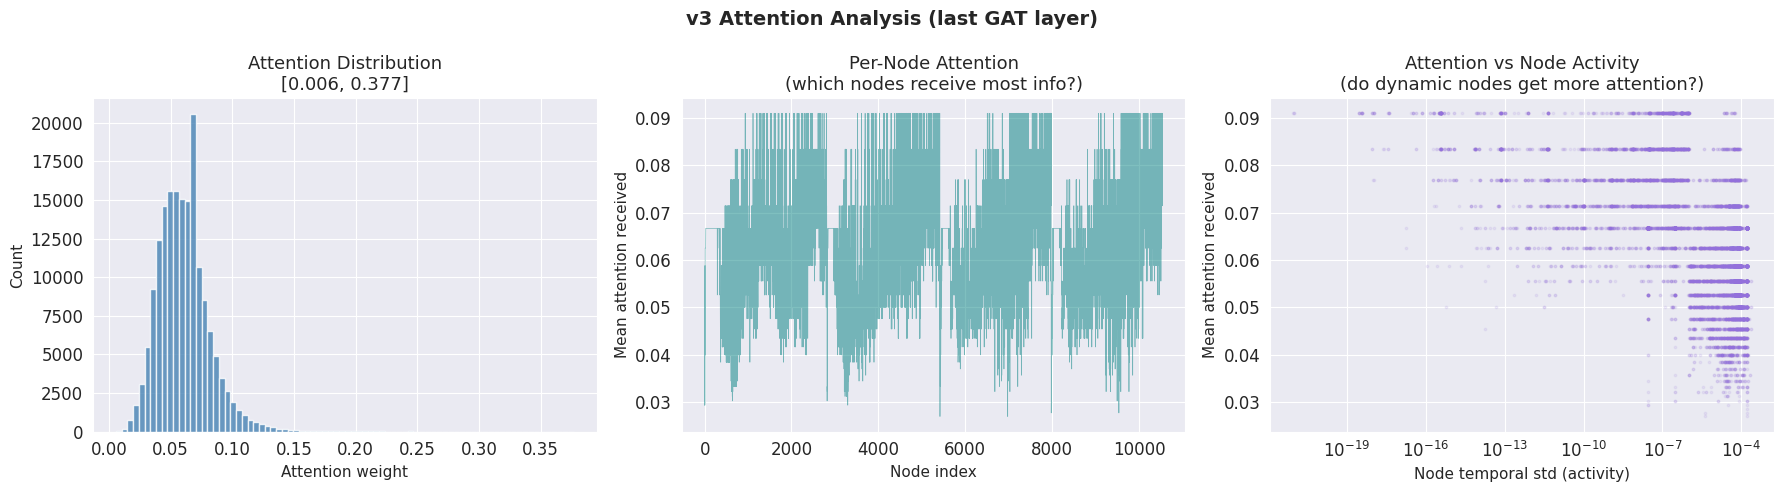

💾 Saved: reports/v3_attention.png


In [71]:
# ═══════════════════════════════════════════════════════════════
# 14. ATTENTION ANALYSIS
# ═══════════════════════════════════════════════════════════════
model.eval()
sd = test_ds[0].to(device)
with torch.no_grad():
    with torch.cuda.amp.autocast(enabled=use_amp):
        _, (ei_a, aw) = model(sd, return_attn=True)

aw_np  = aw.cpu().numpy().flatten()
ei_np  = ei_a.cpu().numpy()

attn_recv = np.zeros(NUM_NODES)
attn_cnt  = np.zeros(NUM_NODES)
for e in range(ei_np.shape[1]):
    d = ei_np[1, e]
    if d < NUM_NODES and e < len(aw_np):
        attn_recv[d] += aw_np[e]; attn_cnt[d] += 1
attn_avg = attn_recv / (attn_cnt + 1e-10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('v3 Attention Analysis (last GAT layer)', fontsize=14, fontweight='bold')

ax = axes[0]
ax.hist(aw_np, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_xlabel('Attention weight'); ax.set_ylabel('Count')
ax.set_title(f'Attention Distribution\n[{aw_np.min():.3f}, {aw_np.max():.3f}]')

ax = axes[1]
ax.plot(attn_avg, alpha=0.5, lw=0.5, color='teal')
ax.set_xlabel('Node index'); ax.set_ylabel('Mean attention received')
ax.set_title('Per-Node Attention\n(which nodes receive most info?)')

ax = axes[2]
valid = attn_cnt > 0
ax.scatter(per_node_std[valid], attn_avg[valid], alpha=0.1, s=3, c='mediumpurple')
ax.set_xscale('log')
ax.set_xlabel('Node temporal std (activity)')
ax.set_ylabel('Mean attention received')
ax.set_title('Attention vs Node Activity\n(do dynamic nodes get more attention?)')

plt.tight_layout()
plt.savefig(str(REPORTS_DIR / 'v3_attention.png'), dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: reports/v3_attention.png")

## 11. Save Model, Predictions & Metrics

In [72]:
# ═══════════════════════════════════════════════════════════════
# 15. SAVE EVERYTHING
# ═══════════════════════════════════════════════════════════════

final_path = str(MODEL_DIR / f"final_gat_v3_{DATASET_NAME}_lb{LOOKBACK}.pt")
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {
        'version': 'v3', 'dataset': DATASET_NAME,
        'lookback': LOOKBACK, 'lookahead': LOOKAHEAD,
        'input_dim': INPUT_DIM,
        'hidden_dim': HIDDEN_DIM, 'num_layers': NUM_LAYERS,
        'num_heads': NUM_HEADS, 'dropout': DROPOUT,
        'k_spatial': K_SPATIAL, 'k_feature': K_FEATURE,
        'lambda_smooth': LAMBDA_SMOOTH,
        'weight_alpha': WEIGHT_ALPHA,
        'warmup_epochs': WARMUP_EPOCHS,
        'num_nodes': NUM_NODES, 'train_epochs': len(train_l),
        'best_val_loss': best_val,
        'delta_mean': float(DELTA_MEAN),
        'delta_std':  float(DELTA_STD),
    },
    'metrics': m,
    'node_weights': node_weights_np,
    'graph_edges': graph_edges,
    'edge_types': EDGE_TYPES,
}, final_path)
print(f"💾 Final model:  {final_path}")
print(f"💾 Best weights: {best_path}")

pred_file = str(REPORTS_DIR / f"v3_test_predictions_{DATASET_NAME}.npz")
np.savez_compressed(pred_file,
    pred_density_original    = pred_orig.astype(np.float32),
    true_density_original    = true_orig.astype(np.float32),
    baseline_density_original= base_orig.astype(np.float32),
    pred_delta               = pred_delta.astype(np.float32),
    true_delta               = raw_true,
    pred_scaled              = pred_z,
    true_scaled              = true_z,
    active_mask              = active_test,
    node_weights             = node_weights_np,
)
print(f"💾 Predictions:  {pred_file}")

def ser(o):
    if isinstance(o, float) and (np.isnan(o) or np.isinf(o)): return str(o)
    if isinstance(o, (np.floating, float)): return float(o)
    if isinstance(o, dict): return {k: ser(v) for k, v in o.items()}
    return o

mpath = str(REPORTS_DIR / f"v3_metrics_{DATASET_NAME}.json")
with open(mpath, 'w') as f:
    json.dump(ser(m), f, indent=2)
print(f"💾 Metrics:      {mpath}")

print("\n" + "═" * 90)
print("📋 v3 FINAL SUMMARY (test set)")
print("═" * 90)
rows = [
    ('R² — scaled delta',            m['scaled_model']['R2'],      m['scaled_baseline']['R2']),
    ('R² — raw delta, active ★',     m['delta_act_model']['R2'],   m['delta_act_base']['R2']),
    ('R² — absolute density, active',m['abs_act_model']['R2'],     m['abs_act_base']['R2']),
    ('MAE — raw delta, active',      m['delta_act_model']['MAE'],  m['delta_act_base']['MAE']),
    ('NRMSE% — raw delta, active',   m['delta_act_model']['NRMSE_pct'], m['delta_act_base']['NRMSE_pct']),
    ('NRMSE% — absolute, all nodes', m['abs_all_model']['NRMSE_pct'],   m['abs_all_base']['NRMSE_pct']),
]
print(f"  {'Metric':<42} {'Model':>15} {'Baseline':>15}  Winner")
print(f"  {'─'*42} {'─'*15} {'─'*15}  {'─'*10}")
for label, mv, bv in rows:
    win = '✅ Model' if (mv > bv if 'R²' in label else mv < bv) else '← Baseline'
    print(f"  {label:<42} {mv:>15.7f} {bv:>15.7f}  {win}")
print("\n✅ v3 complete! All outputs in models/ and reports/")

💾 Final model:  ../models/final_gat_v3_ammonia_x_lb5.pt
💾 Best weights: ../models/best_gat_v3_ammonia_x_lb5.pt
💾 Predictions:  ../reports/v3_test_predictions_ammonia_x.npz
💾 Metrics:      ../reports/v3_metrics_ammonia_x.json

══════════════════════════════════════════════════════════════════════════════════════════
📋 v3 FINAL SUMMARY (test set)
══════════════════════════════════════════════════════════════════════════════════════════
  Metric                                               Model        Baseline  Winner
  ────────────────────────────────────────── ─────────────── ───────────────  ──────────
  R² — scaled delta                               -0.0000086      -0.0000001  ← Baseline
  R² — raw delta, active ★                        -0.0000059      -0.0000000  ← Baseline
  R² — absolute density, active                    1.0000000       1.0000000  ← Baseline
  MAE — raw delta, active                          0.0000520       0.0000520  ← Baseline
  NRMSE% — raw delta, active    